# Introduction

- SuppFig 7D-E: Cell Distance to Epithelium Distribution
- Histogram of T cell and Myeloid cell distance to nearest Epithelial cell.

In [1]:
fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}
library(purrr)
library(dplyr)
library(ggplot2)
library(ggthemes)
library(FNN)

Warning message:
“package ‘purrr’ was built under R version 4.1.3”
Warning message:
“package ‘dplyr’ was built under R version 4.1.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Read

In [ ]:
fdir <- file.path(".")

cell_meta <- readRDS(file.path(fdir, "cell_meta.rds"))

# Annotate distance

In [3]:
compute_nn_dist <- function(
    df,
    target,
    celltype_col,
    sample_col="new_specimenID",
    x_col="x_mod",
    y_col="y_mod"
){
    df <- as.data.frame(df)
    out_df <- purrr::map(unique(df[[sample_col]]), function(.sample){
        sub_df <- df %>% 
            filter(.data[[sample_col]] == .sample)
        ref_df <- sub_df %>% 
            filter(.data[[celltype_col]] == target)
        sub_df[[paste0("dist_to_", target)]] <- knnx.dist(
            data=as.matrix(ref_df[, c(x_col, y_col)]),
            query=as.matrix(sub_df[, c(x_col, y_col)]), k=1)[, 1]
        return(sub_df)
    }) %>% 
    bind_rows()
    return(out_df)
}

In [4]:
cell_meta <- compute_nn_dist(
    df=cell_meta, target="Epithelial", celltype_col="celltype_level_1")

Warning message:
“Removed 1436 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


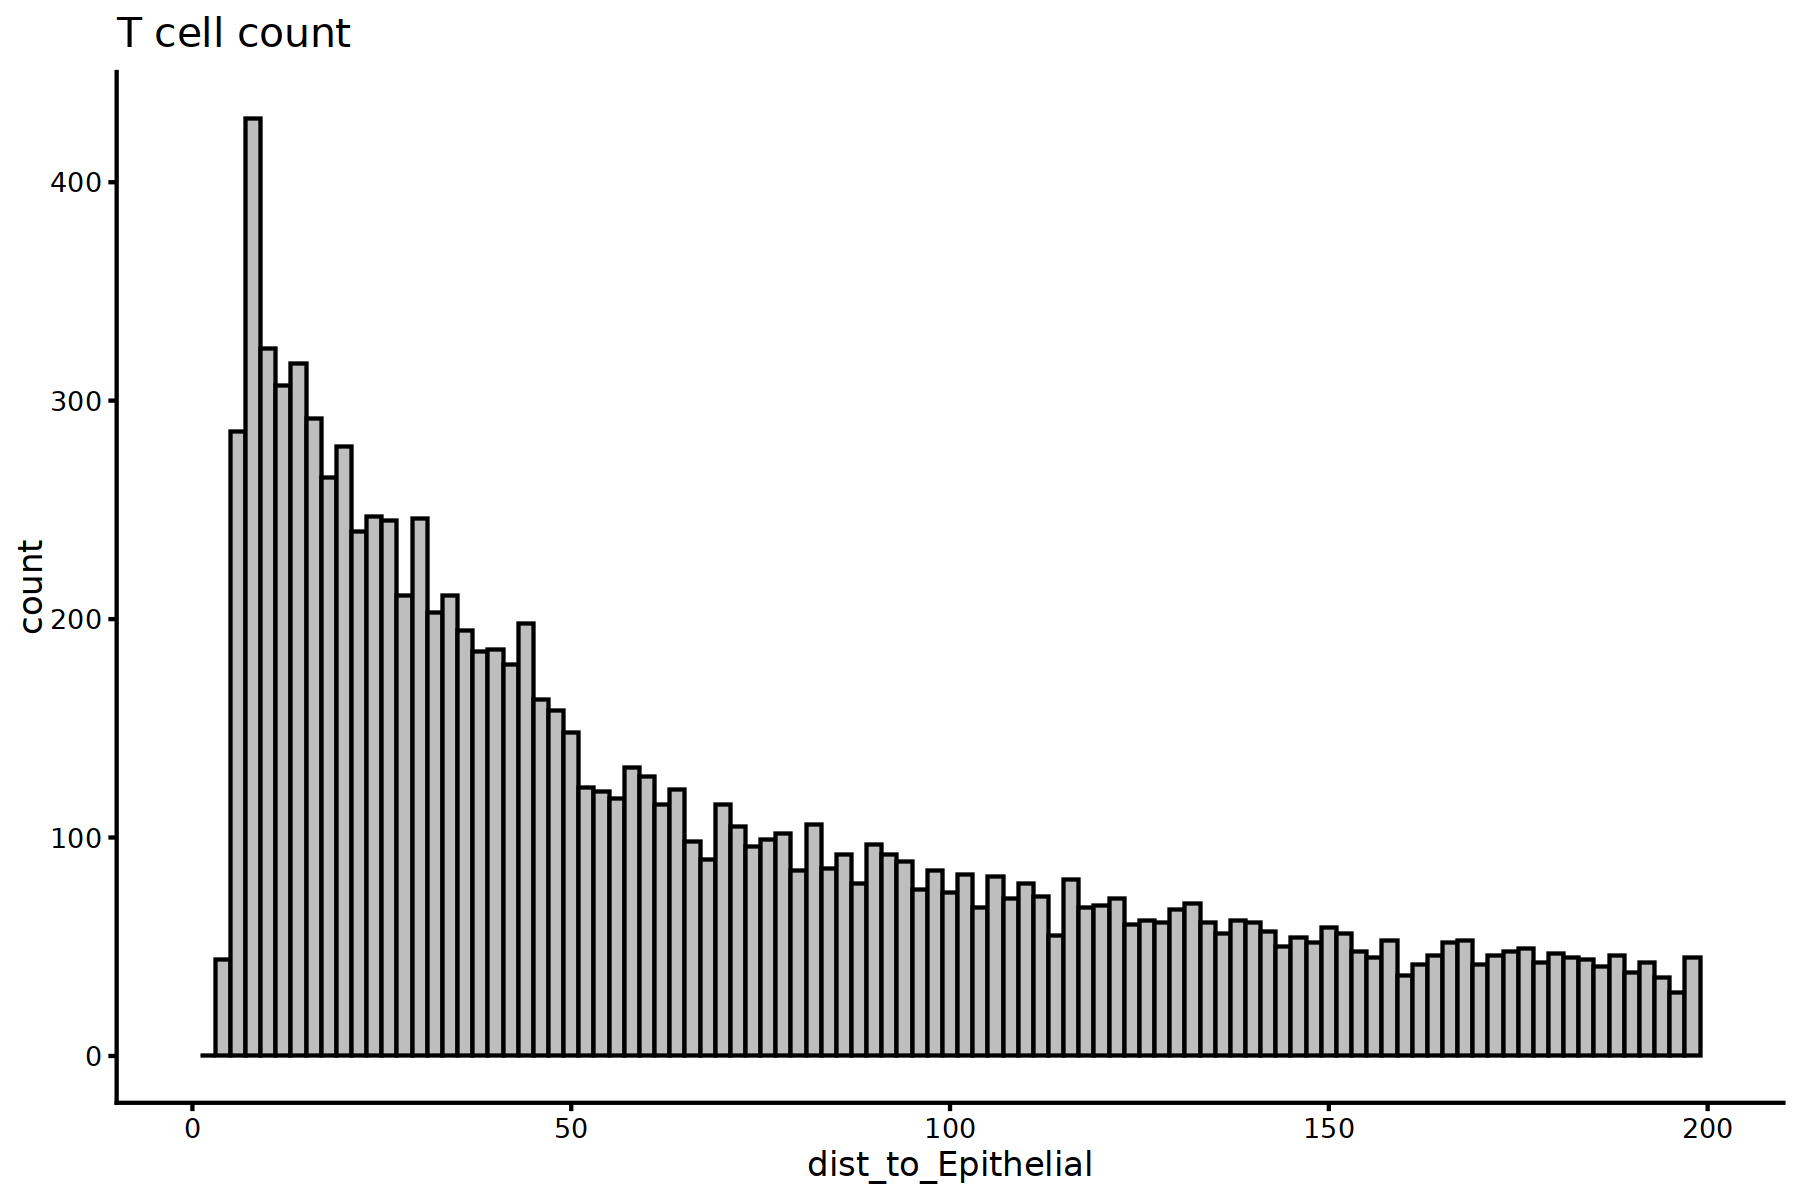

In [5]:
.celltype <- "T"
title <- paste0(.celltype, " cell count")
p <- cell_meta %>% 
    filter(celltype_level_1 == .celltype) %>% 
    ggplot(aes(x = dist_to_Epithelial)) +
        geom_histogram(color = "black", fill = "gray", binwidth = 2) +
        scale_x_continuous(limits = c(0, 200)) +
        theme_classic(base_size =20) +
        labs(title = title) +
        NULL

fig.size(10, 15)
p

Warning message:
“Removed 4041 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


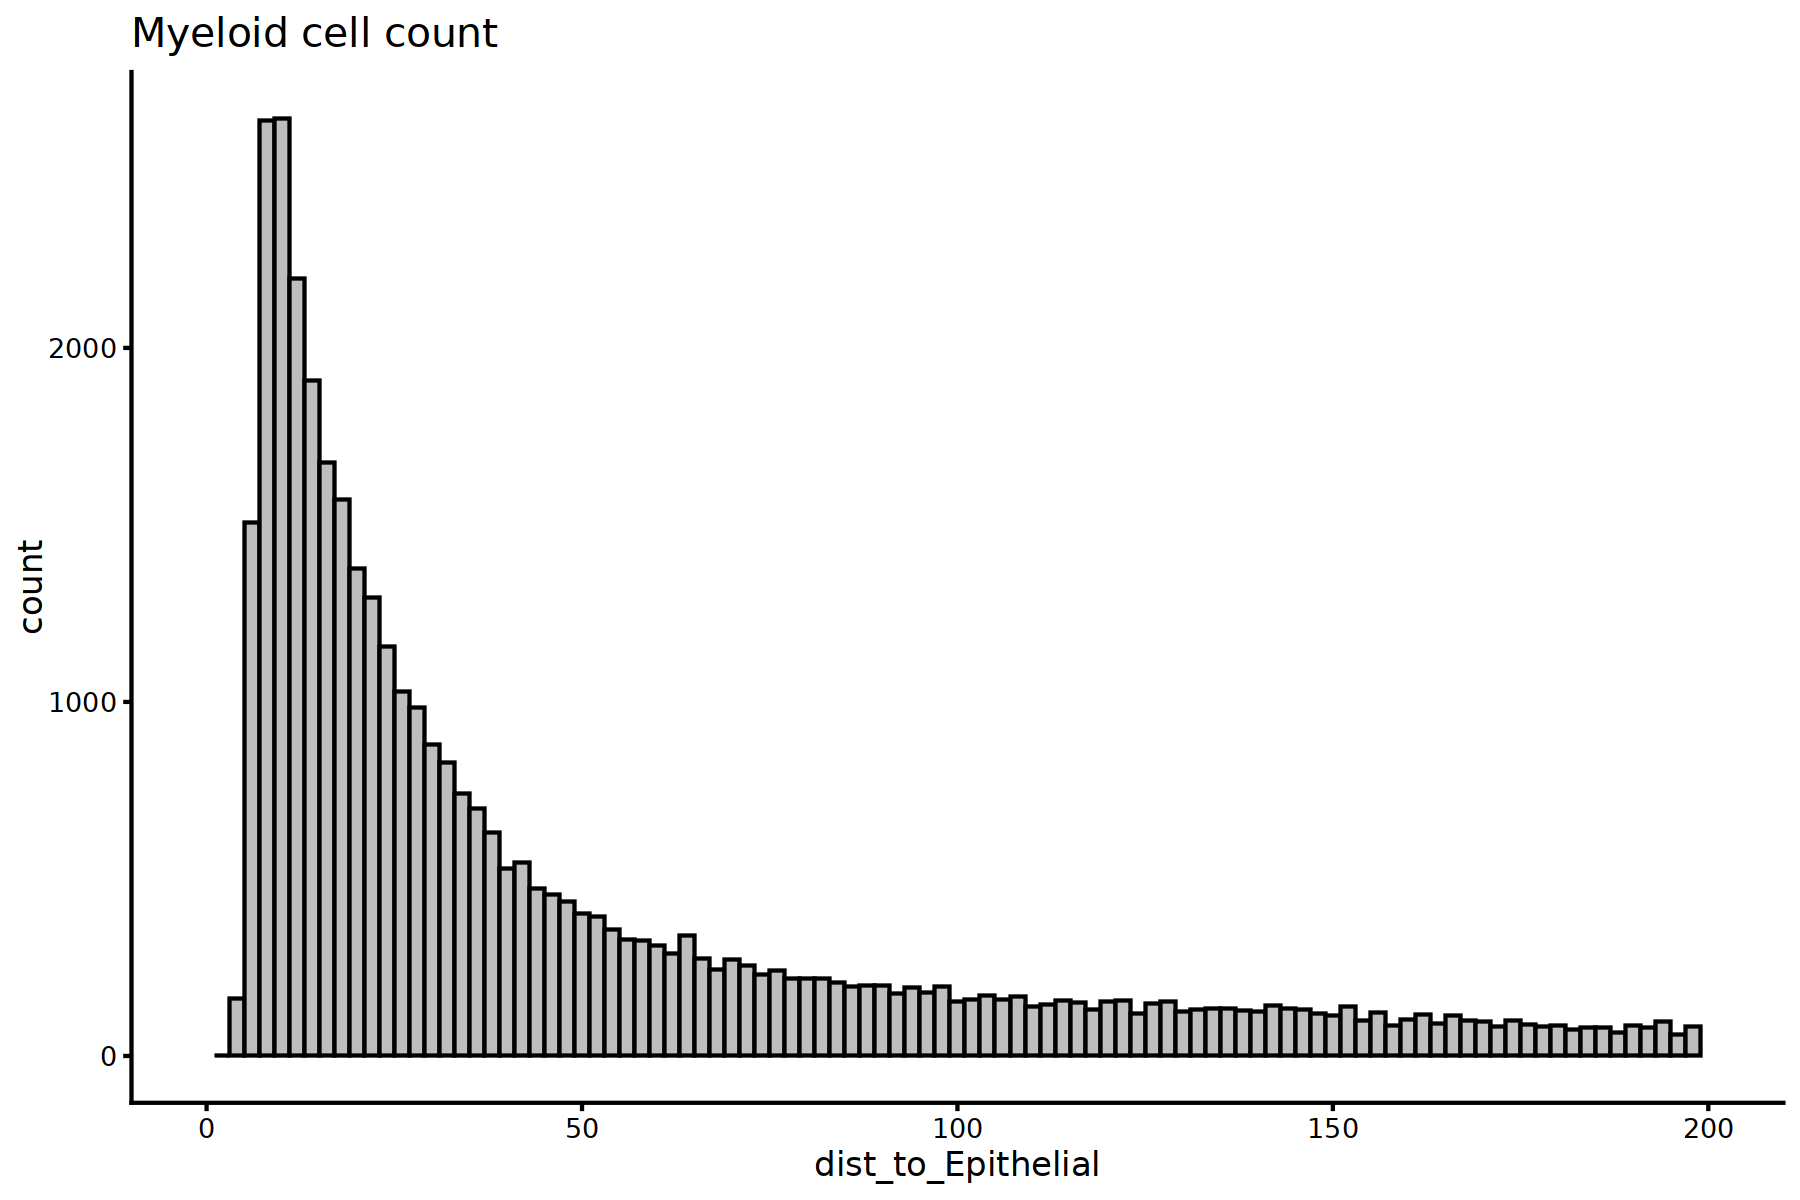

In [6]:
.celltype <- "Myeloid"
title <- paste0(.celltype, " cell count")
p <- cell_meta %>% 
    filter(celltype_level_1 == .celltype) %>% 
    ggplot(aes(x = dist_to_Epithelial)) +
        geom_histogram(color = "black", fill = "gray", binwidth = 2) +
        scale_x_continuous(limits = c(0, 200)) +
        theme_classic(base_size =20) +
        labs(title = title) +
        NULL

fig.size(10, 15)
p

In [7]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.7 (Plow)

Matrix products: default
BLAS/LAPACK: /home/hoy821/miniforge3/lib/libopenblasp-r0.3.24.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] FNN_1.1.4.1    ggthemes_4.2.4 ggplot2_4.0.1  dplyr_1.1.2    purrr_1.0.1   

loaded via a namespace (and not attached):
 [1] pillar_1.11.1      compiler_4.1.2     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.1.2        digest_0.6.31      uuid_1.1-0         jsonlite_1.8.7    
 [9] evaluate_